In [1]:
!nvidia-smi

Tue Aug 18 12:14:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [3]:
# Install latest ultralytics (required for YOLO26 support)
%pip install -q -U ultralytics supervision roboflow
# Disable Ultralytics telemetry
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 47.3/235.7 GB disk)


In [4]:
# Sanity check: run pretrained YOLO26n on a sample image
!yolo task=detect mode=predict model=yolo26n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.5 GFLOPs

image 1/1 /content/dog.jpeg: 640x384 1 person, 1 dog, 1 backpack, 10.9ms
Speed: 56.1ms preprocess, 10.9ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


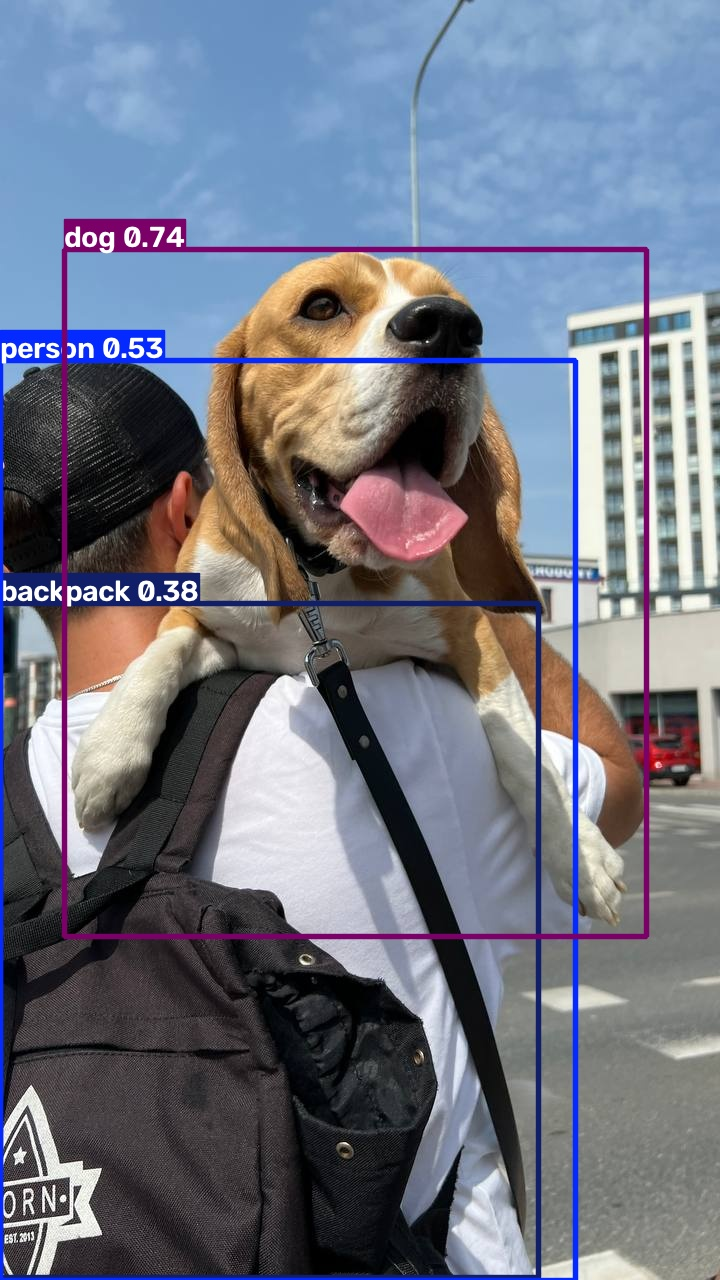

In [5]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpg', width=600)

In [6]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo26n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 1 person, 1 dog, 1 backpack, 11.2ms
Speed: 25.1ms preprocess, 11.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)


In [7]:
result.boxes.xyxy

tensor([[  64.0600,  249.8738,  646.4449,  936.8276],
        [   0.0000,  360.5178,  575.5292, 1280.0000],
        [   0.0000,  603.2538,  538.0580, 1277.0112]], device='cuda:0')

In [8]:
result.boxes.conf

tensor([0.7426, 0.5272, 0.3755], device='cuda:0')

In [9]:
result.boxes.cls

tensor([16.,  0., 24.], device='cuda:0')

In [10]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

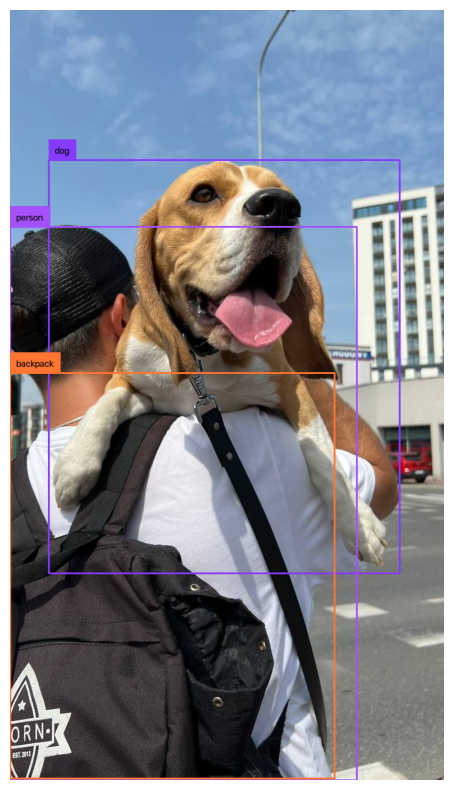

In [11]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

In [12]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("renaire-odarve")
project = workspace.project("erotica-detection")
version = project.version(4)
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to erotica-detection-4 in yolov11:: 100%|██████████| 31628/31628 [00:03<00:00, 8703.37it/s]


In [13]:
%cd {HOME}

!yolo task=detect mode=train model=yolo26n.pt data={dataset.location}/data.yaml epochs=150 imgsz=640 plots=True

/content
Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/erotica-detection-4/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0

In [14]:
!ls {HOME}/runs/detect/train/

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg      val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg      val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch96880.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch96881.jpg  weights
labels.jpg			 train_batch96882.jpg


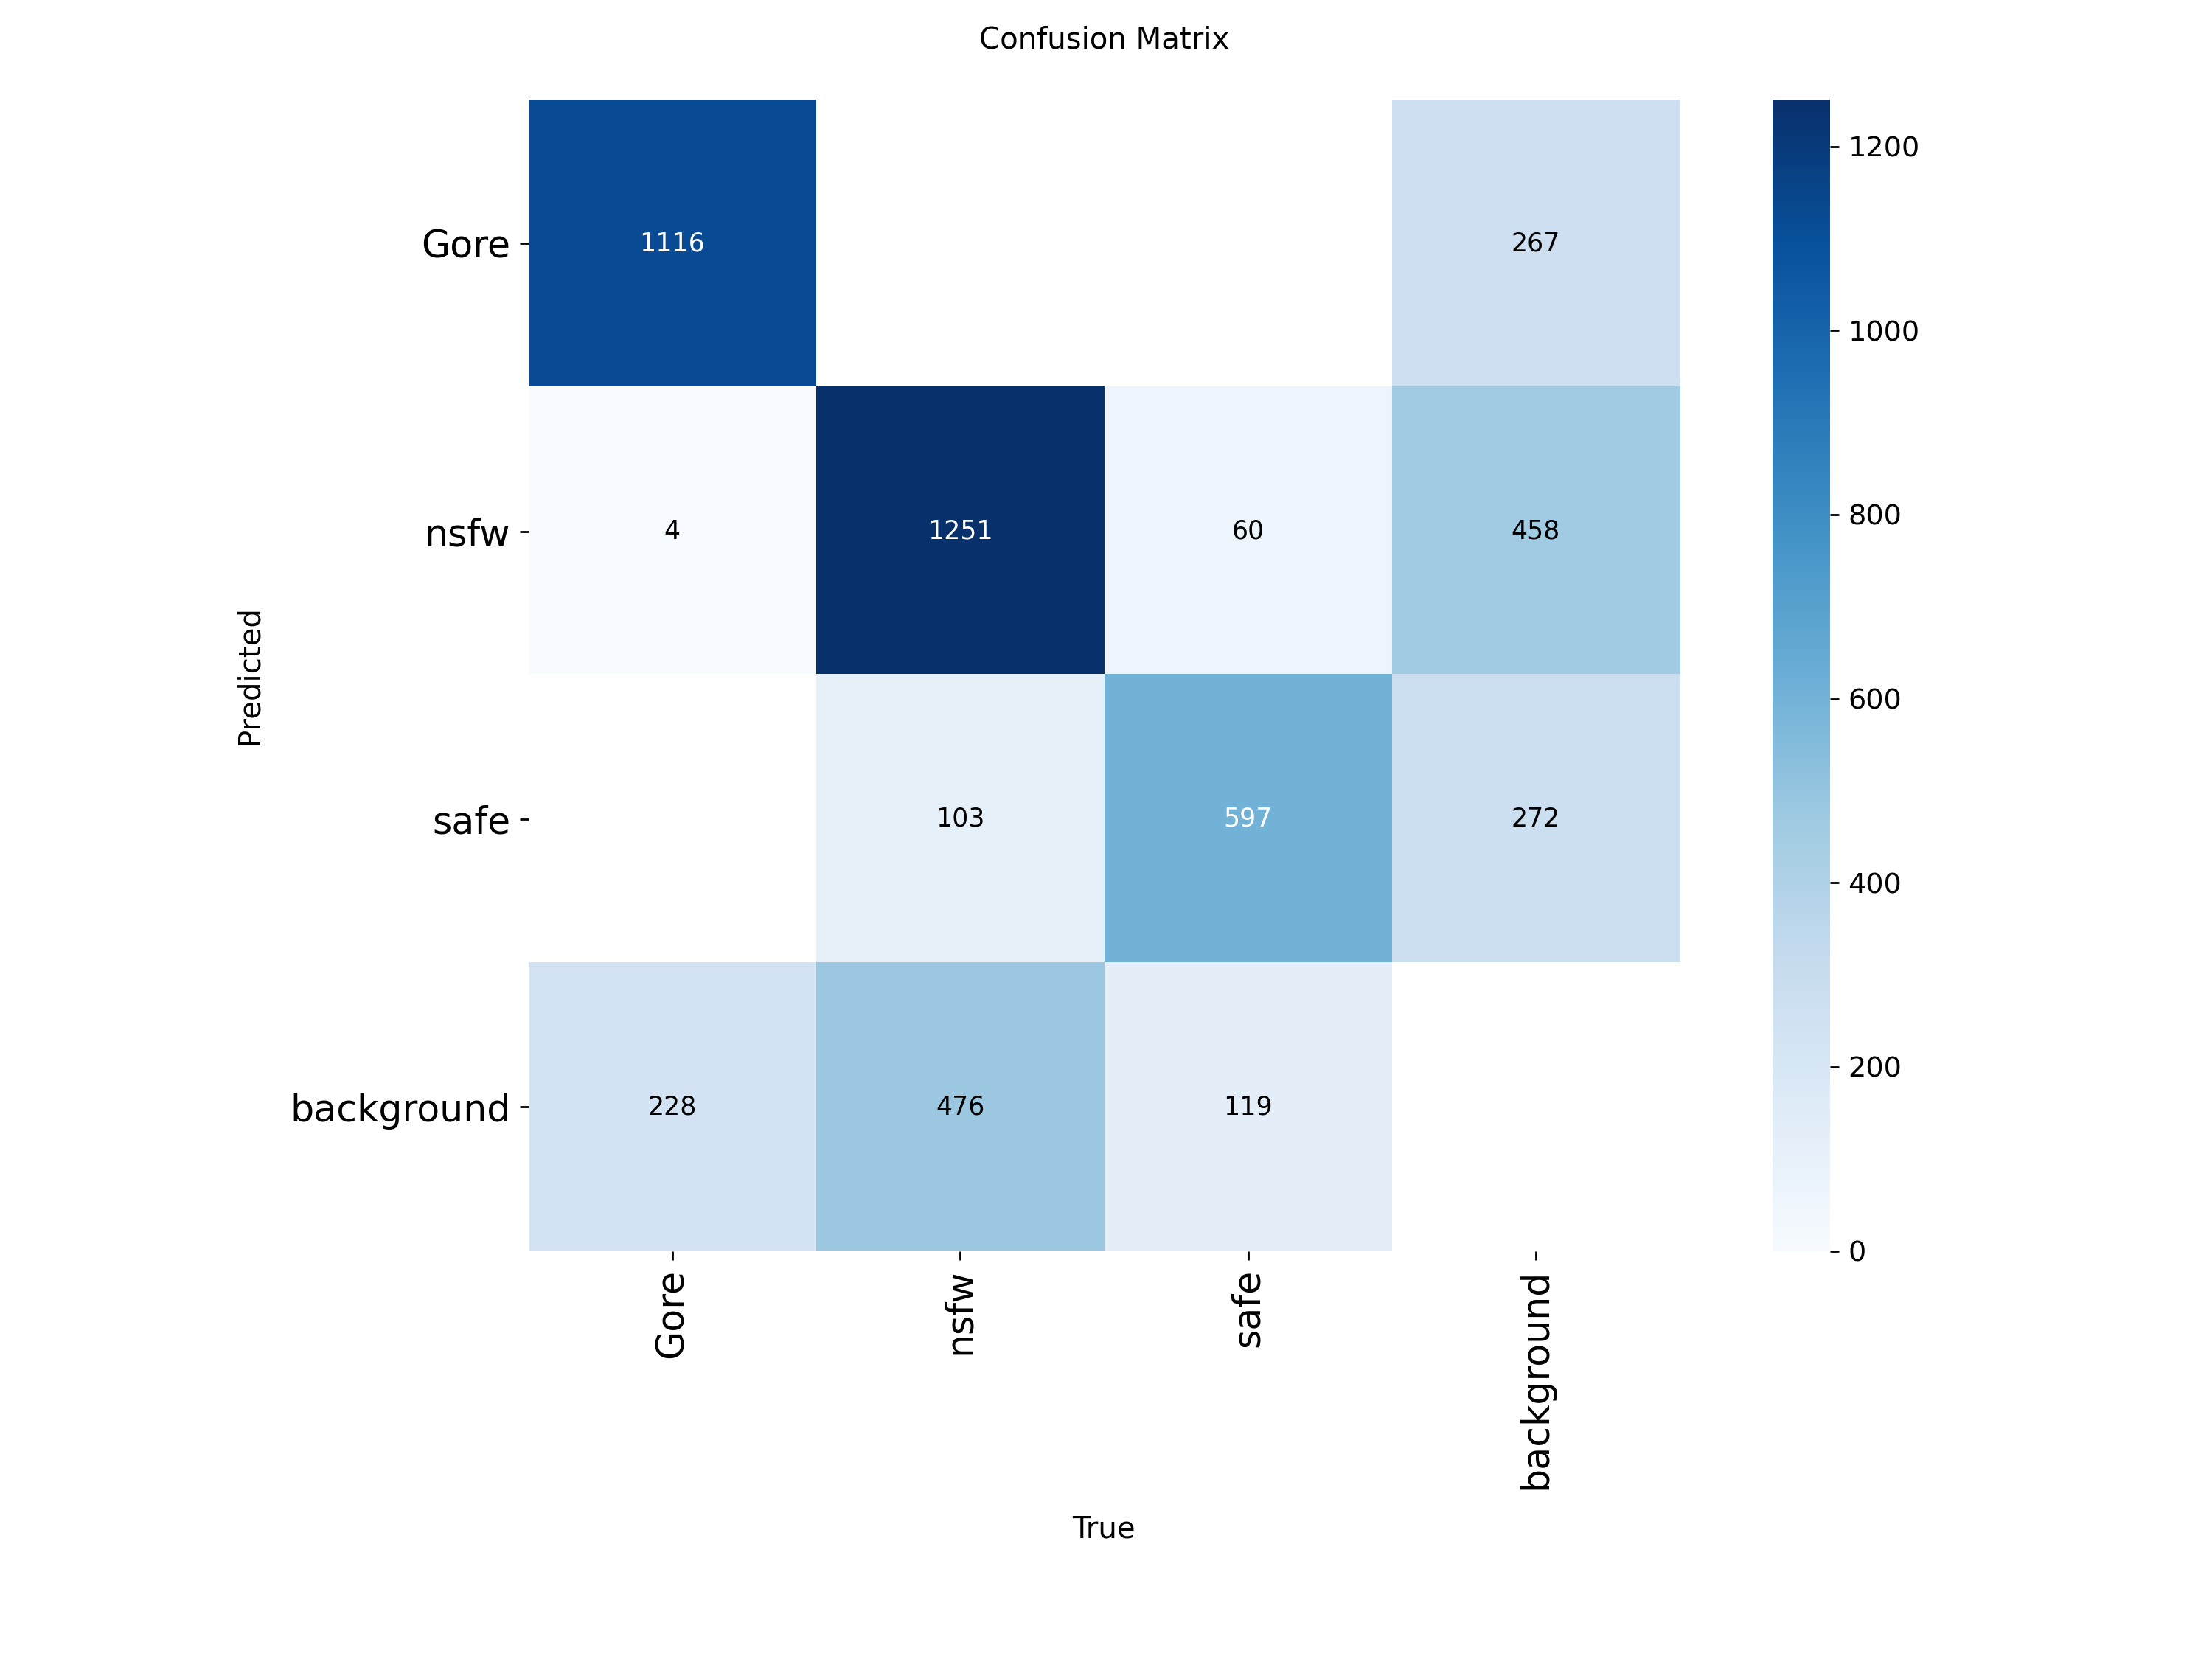

In [15]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

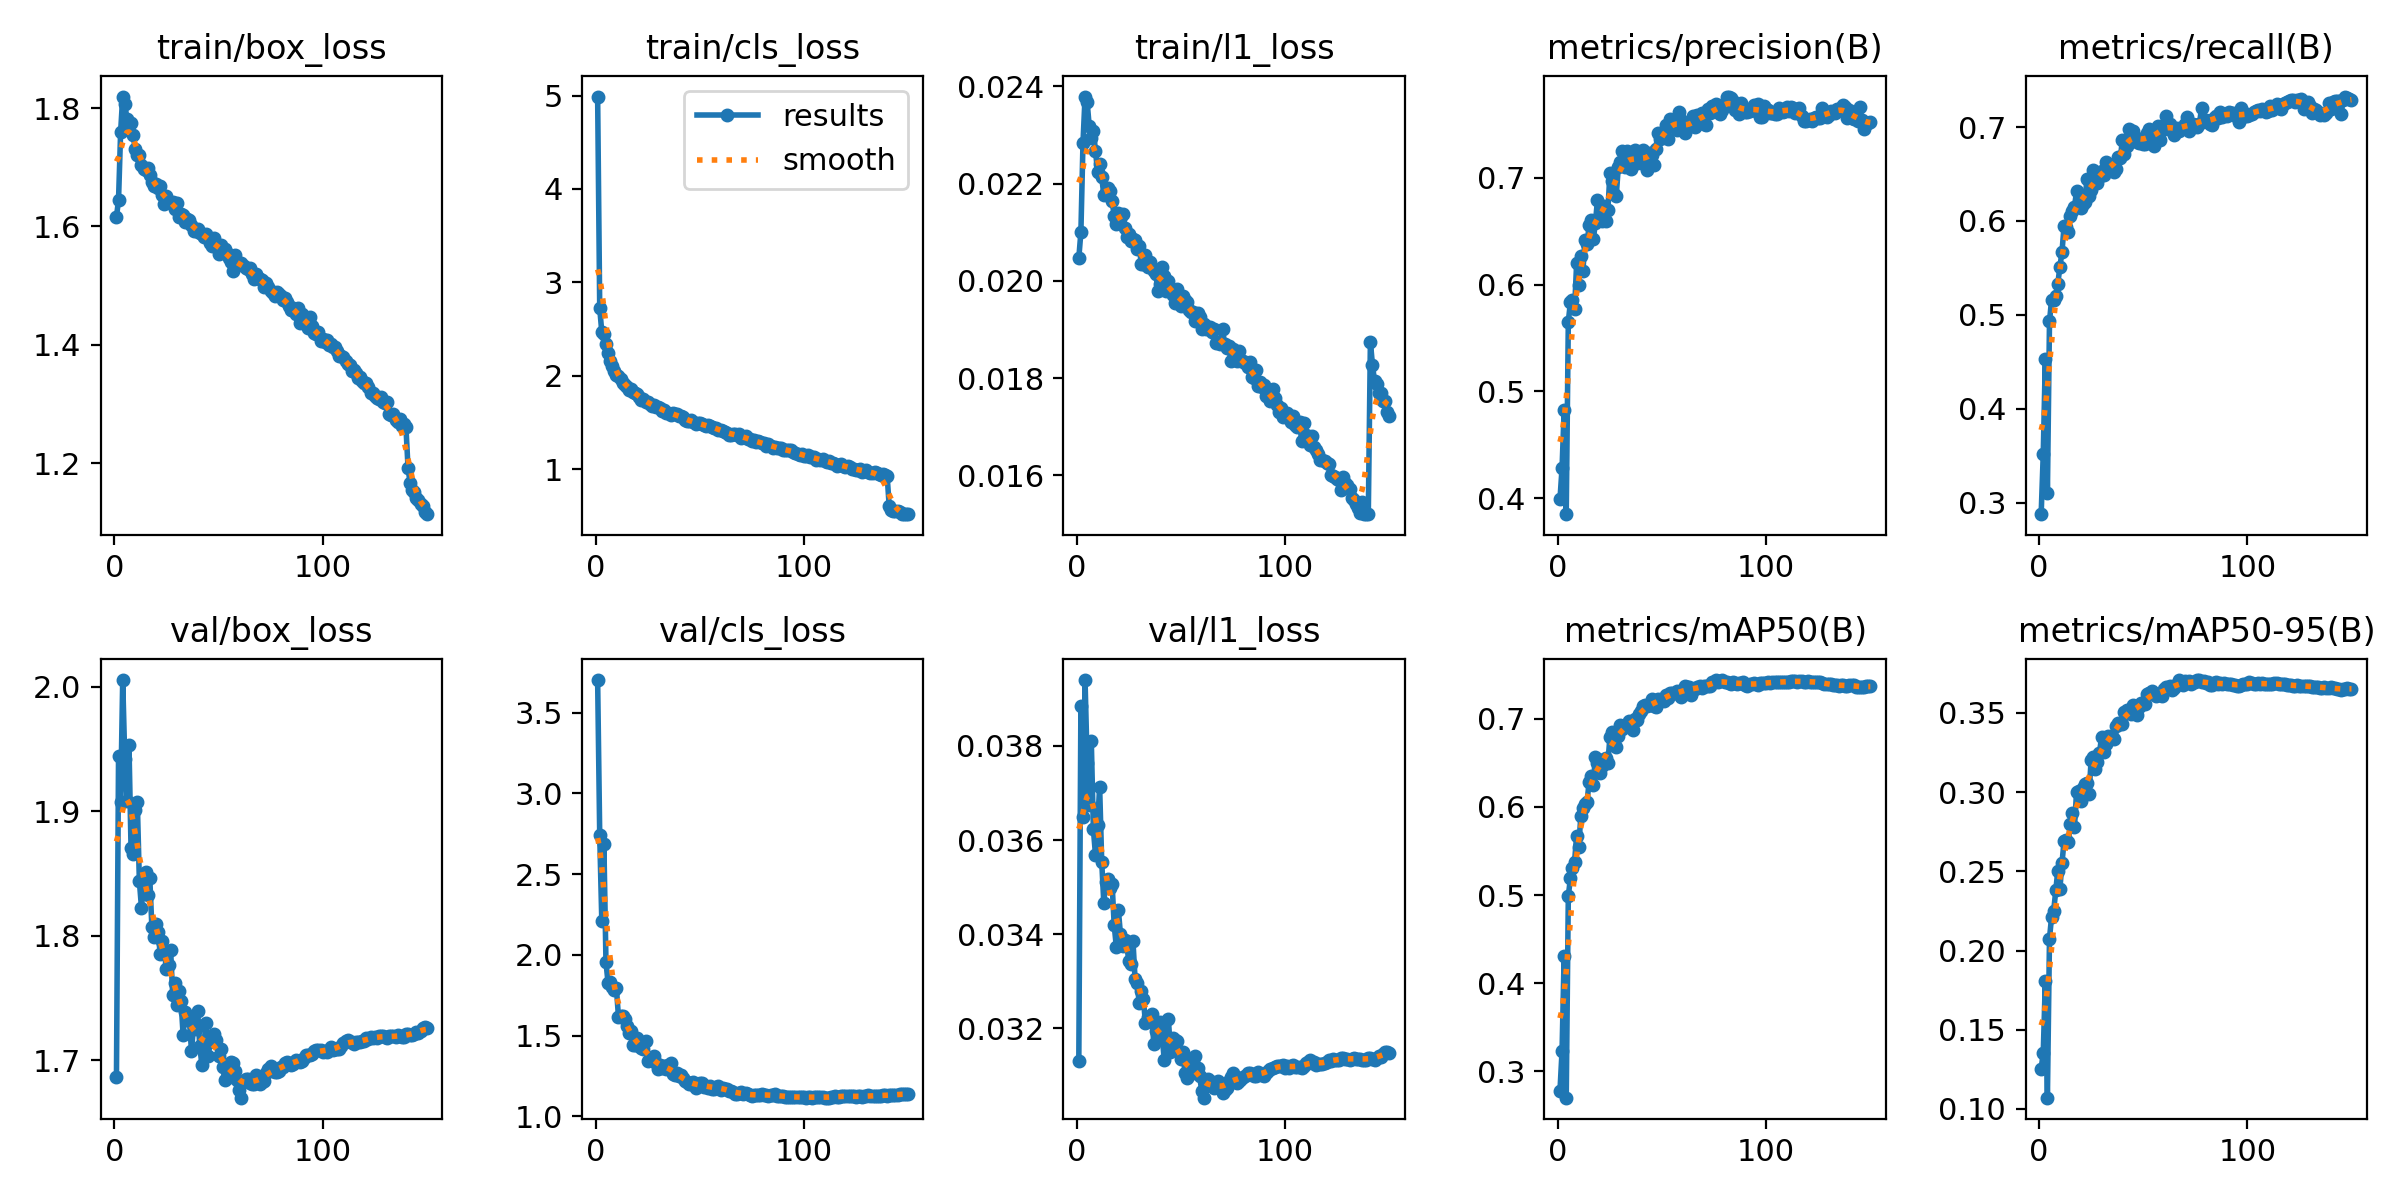

In [16]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

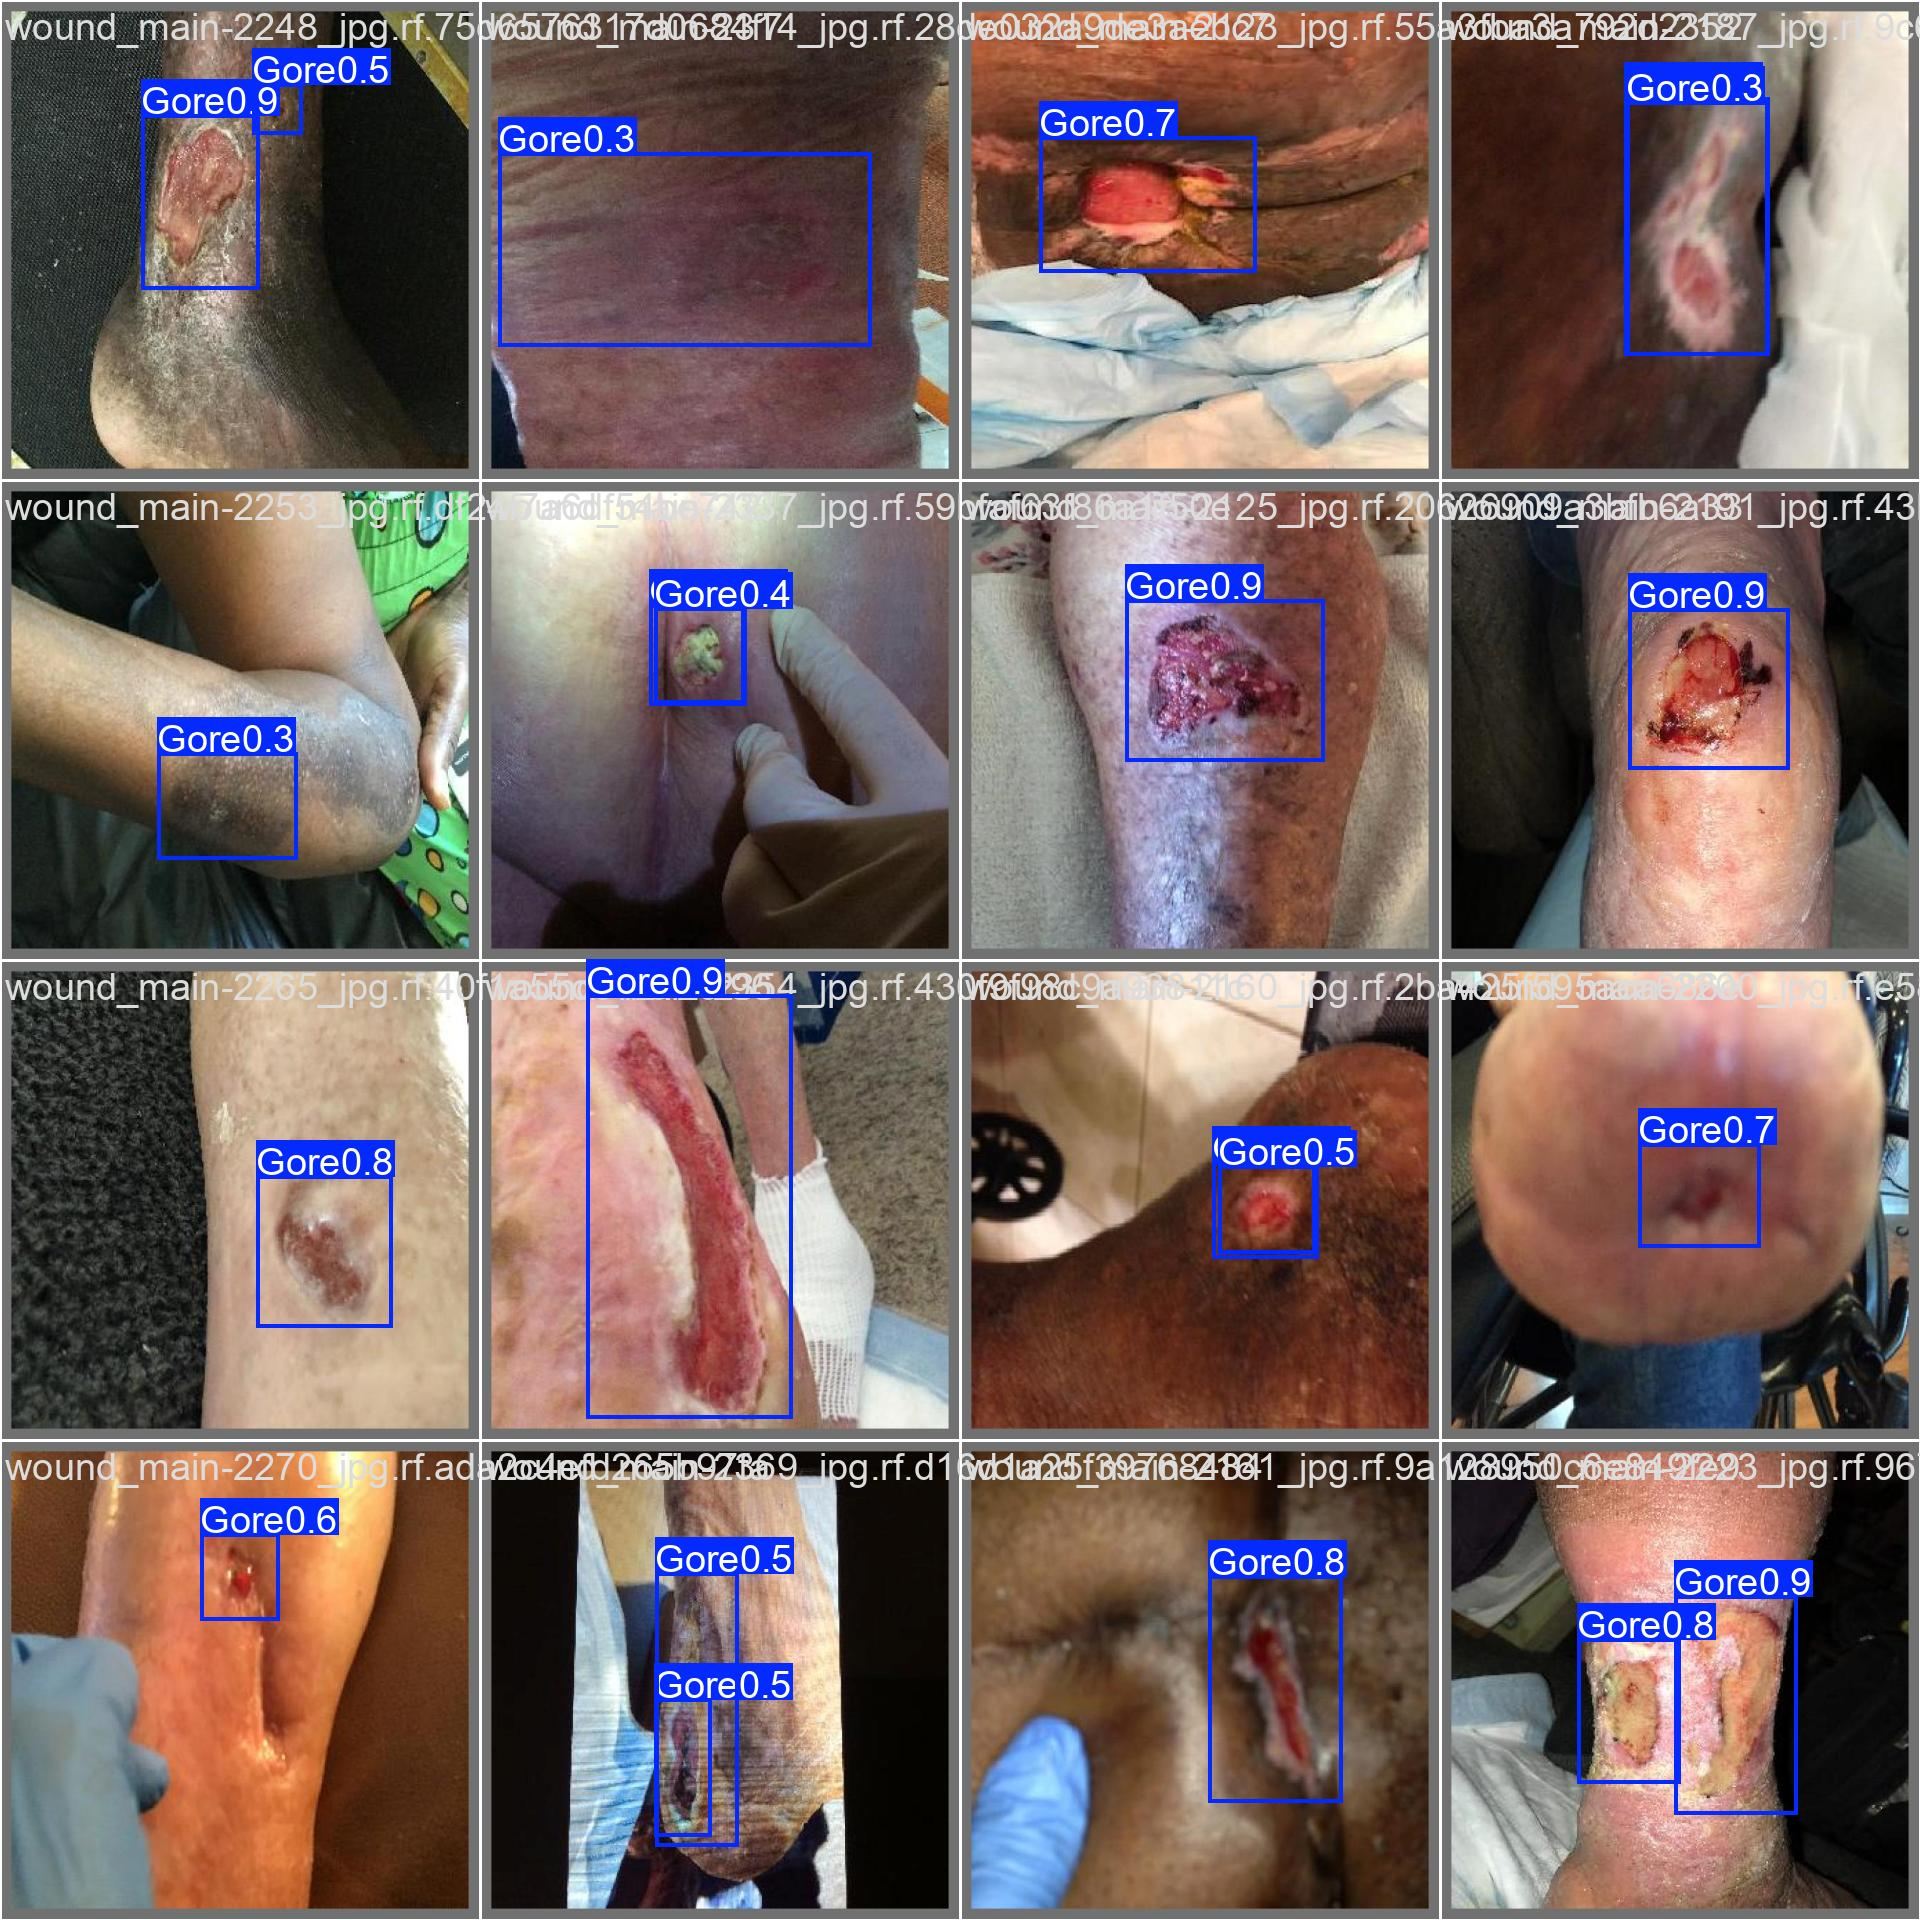

In [17]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [18]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1544.0±646.4 MB/s, size: 40.7 KB)
val: Scanning /content/datasets/erotica-detection-4/valid/labels.cache... 2416 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2416/2416 422.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 151/151 14.1it/s 10.7s
                   all       2416       3954      0.763      0.703      0.742       0.37
                  Gore       1025       1348      0.867      0.785      0.866      0.521
                  nsfw        978       1830      0.746      0.619      0.681      0.304
                  safe        520        776      0.676      0.706      0.679      0.287
Speed: 0.7ms preprocess, 0.9ms inference, 0.0ms loss, 0.1ms postprocess per image
Results sa

In [19]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs

image 1/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0000-978B3Ab05B7D2D1179E42B02C89Bd98875D1Bd38-01E2H07W3_jpg.rf.fdd846755455ae656df403e62f440965.jpg: 640x640 1 nsfw, 11.1ms
image 2/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0001-6-01G12Q6Djrcnq295Zx6Tpnwtaw1680X0_jpg.rf.dd8fb3ba0cc82f539367f433c03e747e.jpg: 640x640 2 nsfws, 11.1ms
image 3/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0005-10-01G145H5V5Z86Gfbhhzqfbqkbv1680X0_jpg.rf.b88ff47921aa69035cc45a3f4ea578a6.jpg: 640x640 2 nsfws, 10.9ms
image 4/2327 /content/datasets/erotica-detection-4/test/images/9Cloud-us_0007-K15Ujdhhans81-01G0N767Qxfk8F3Bpvkdbg8Bws640X0_jpg.rf.6fab970148da2e8dfeb8db40f7cf0803.jpg: 640x640 2 nsfws, 10.7ms
image 5/2327 /content/datasets/erotica-detection-4/test/images/9

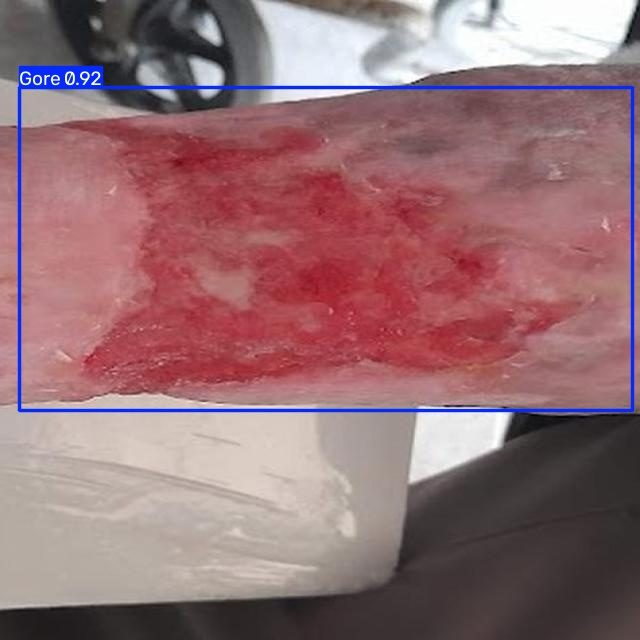

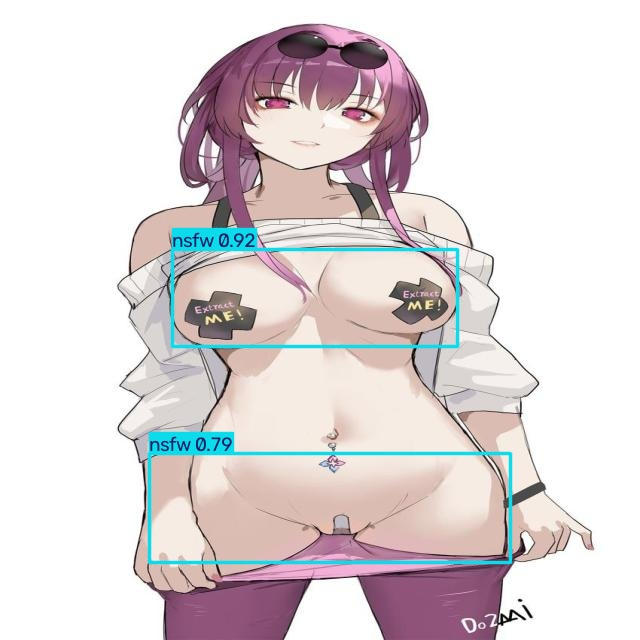

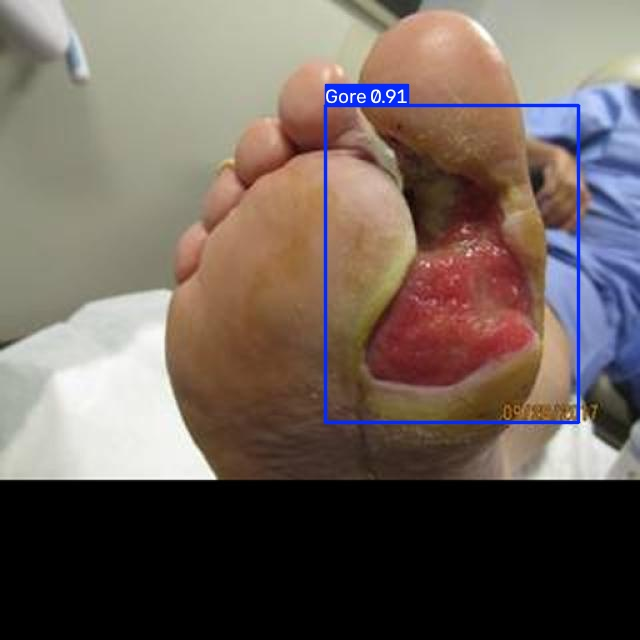

In [20]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [21]:
# Export the fine-tuned model to TFLite for Android Studio
# Produces float32 and float16 .tflite files inside best_saved_model/
# Note: if ultralytics warns about tflite being deprecated, use format='litert' instead
from ultralytics import YOLO

best_model = YOLO(f'{HOME}/runs/detect/train/weights/best.pt')
best_model.export(format='tflite')

WARNING ⚠️ format='tflite' is deprecated as of 8.4.83 and has been replaced by the unified Google LiteRT format. Exporting format='litert' instead. See https://docs.ultralytics.com/integrations/litert/
Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.2 MB)
requirements: Ultralytics requirements ['litert-torch>=0.9.0', 'ai-edge-litert>=2.1.4'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 85 packages in 817ms
Prepared 15 packages in 1.58s
Uninstalled 3 packages in 34ms
Installed 15 packages in 18ms
 + ai-edge-litert==2.1.6
 + ai-edge-quantizer==0.8

invalid escape sequence '\.'



LiteRT: starting export with litert_torch 0.9.3...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:18) [ DONE] LiteRT-Torch Convert (+00:18)

(00:00) [START] Write Model to /content/runs/detect/train/weights/best.tflite

(00:00) [ DONE] Write Model to /content/runs/detect/train/weights/best.tflite (+00:00)

LiteRT: export success ✅ 24.5s, saved as '/content/runs/detect/train/weights/best.tflite' (9.4 MB)

Export complete (24.9s)
Results saved to /content/runs/detect/train/weights/best.tflite
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best.tflite imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best.tflite imgsz=640 data=/content/datasets/erotica-detection-4/data.yaml  
Visualize:       https://netron.app


PosixPath('/content/runs/detect/train/weights/best.tflite')

In [22]:
# Confirm export files exist
import glob
tflite_files = glob.glob(f'{HOME}/runs/detect/train/weights/best_saved_model/**/*.tflite', recursive=True)
print("TFLite files:", tflite_files)

TFLite files: []


In [23]:
# Zip training results
!zip -r yolov26n_results.zip /content/runs/detect/train/

  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/BoxF1_curve.png (deflated 10%)
  adding: content/runs/detect/train/train_batch2.jpg (deflated 3%)
  adding: content/runs/detect/train/val_batch0_pred.jpg (deflated 8%)
  adding: content/runs/detect/train/BoxR_curve.png (deflated 11%)
  adding: content/runs/detect/train/results.csv (deflated 70%)
  adding: content/runs/detect/train/results.png (deflated 8%)
  adding: content/runs/detect/train/confusion_matrix_normalized.png (deflated 26%)
  adding: content/runs/detect/train/train_batch96880.jpg (deflated 9%)
  adding: content/runs/detect/train/val_batch2_pred.jpg (deflated 10%)
  adding: content/runs/detect/train/train_batch96881.jpg (deflated 7%)
  adding: content/runs/detect/train/train_batch1.jpg (deflated 3%)
  adding: content/runs/detect/train/train_batch96882.jpg (deflated 4%)
  adding: content/runs/detect/train/BoxP_curve.png (deflated 9%)
  adding: content/runs/detect/train/weights/ (stored 0%)


In [24]:
# Zip the exported TFLite model
!zip -r yolov26n_saved_model.zip /content/runs/detect/train/weights/best_saved_model

	zip warning: name not matched: /content/runs/detect/train/weights/best_saved_model

zip error: Nothing to do! (try: zip -r yolov26n_saved_model.zip . -i /content/runs/detect/train/weights/best_saved_model)


In [25]:
from google.colab import files

files.download('yolov26n_results.zip')
files.download('yolov26n_saved_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: yolov26n_saved_model.zip

In [26]:
# Zip the exported TFLite model
!zip -r yolov26n_saved_model.zip /content/runs/detect/train/weights/best.tflite

  adding: content/runs/detect/train/weights/best.tflite (deflated 13%)


In [27]:
from google.colab import files

files.download('yolov26n_saved_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>